In [7]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import BaseEstimator, ClassifierMixin

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv('D:\study\semster 2 year 3\XAI\XAI github\cardiovascular_fe.csv')
df.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
4,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


In [3]:
target = "CARDIO_DISEASE"

selected_features = [
    "AGE", "GENDER", "BMI", "MAP", "PULSE_PRESSURE",
    "CHOLESTEROL", "GLUCOSE", "SMOKE", "ALCOHOL", "PHYSICAL_ACTIVITY"
]

X = df[selected_features].copy()
y = df[target].copy()

print("Selected features:", selected_features)
print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

Selected features: ['AGE', 'GENDER', 'BMI', 'MAP', 'PULSE_PRESSURE', 'CHOLESTEROL', 'GLUCOSE', 'SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY']
X shape: (62513, 10)
y shape: (62513,)


,AGE,GENDER,BMI,MAP,PULSE_PRESSURE,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY
0,50,2,21.967120,90.000000,30,1,1,0,0,1
1,55,1,34.927679,106.666667,50,3,1,0,0,1
2,52,1,23.507805,90.000000,60,3,1,0,0,0
3,48,2,28.710479,116.666667,50,1,1,0,0,1
4,60,1,29.384676,93.333333,40,2,2,0,0,0


In [4]:
# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

In [6]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Neural networks need 3D shape for attention: (samples, features, channels)
n_features = X_train_scaled.shape[1]

X_train_nn = X_train_scaled.reshape(-1, n_features, 1)
X_val_nn = X_val_scaled.reshape(-1, n_features, 1)
X_test_nn = X_test_scaled.reshape(-1, n_features, 1)

print("Neural network training shape:", X_train_nn.shape)
print("Neural network validation shape:", X_val_nn.shape)
print("Neural network testing shape:", X_test_nn.shape)

Neural network training shape: (42508, 10, 1)
Neural network validation shape: (7502, 10, 1)
Neural network testing shape: (12503, 10, 1)


In [8]:
def build_attention_model(n_features):
    inputs = Input(shape=(n_features, 1))

    # Convert each feature value into a small embedding
    x = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)

    # Self-attention over features
    attn_output = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    x = LayerNormalization()(x + attn_output)

    # Summarize feature interactions
    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.40)(x)

    x = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=["accuracy", AUC(name="auc")]
    )
    return model

attention_model = build_attention_model(n_features)
attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 32)    │         64 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 32)    │        128 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 32)    │      4,224 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [9]:
early_stop = EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    factor=0.5,
    patience=5,
    mode="max",
    min_lr=1e-6,
    verbose=1
)

history = attention_model.fit(
    X_train_nn,
    y_train,
    validation_data=(X_val_nn, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6227 - auc: 0.6669 - loss: 0.7947 - val_accuracy: 0.5817 - val_auc: 0.6972 - val_loss: 0.7509 - learning_rate: 5.0000e-04
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6553 - auc: 0.7052 - loss: 0.7247 - val_accuracy: 0.6861 - val_auc: 0.7474 - val_loss: 0.7066 - learning_rate: 5.0000e-04
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6650 - auc: 0.7194 - loss: 0.6987 - val_accuracy: 0.6834 - val_auc: 0.7422 - val_loss: 0.6774 - learning_rate: 5.0000e-04
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6729 - auc: 0.7274 - loss: 0.6841 - val_accuracy: 0.6918 - val_auc: 0.7520 - val_loss: 0.6535 - learning_rate: 5.0000e-04
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6811 - auc: 0.7338 - loss: 0.6713 - val_accuracy: 0.6977 - val_auc: 0.7541 - val_loss: 0.6582 - learning_rate: 5.0000e-04
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/s

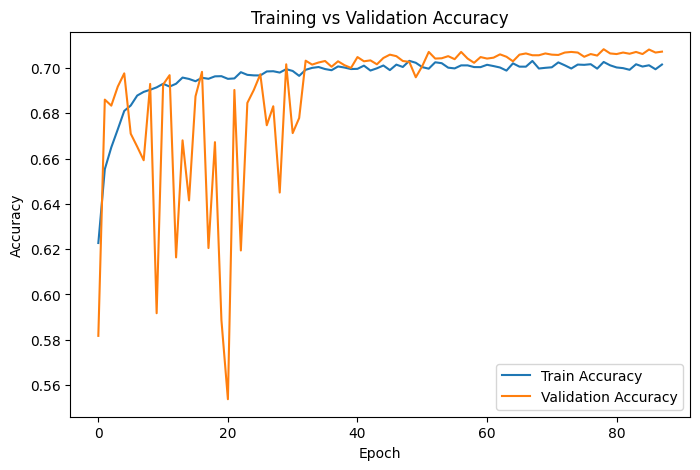

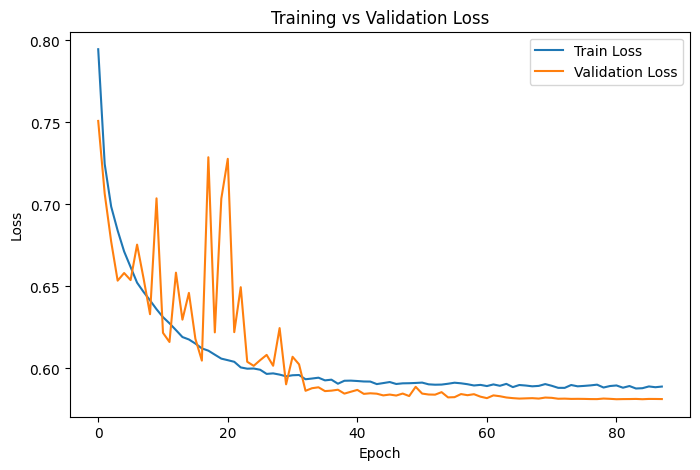

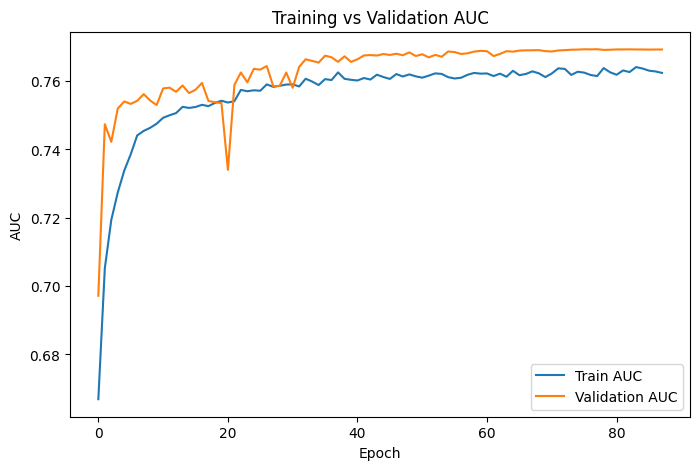

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training vs Validation AUC")
plt.legend()
plt.show()

In [12]:
def evaluate_predictions(y_true, y_pred, y_prob, model_name="Model"):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    return results

train_prob = attention_model.predict(X_train_nn).ravel()
val_prob = attention_model.predict(X_val_nn).ravel()
test_prob = attention_model.predict(X_test_nn).ravel()

train_pred = (train_prob >= 0.5).astype(int)
val_pred = (val_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

train_results = evaluate_predictions(y_train, train_pred, train_prob, "Attention NN - Train")
val_results = evaluate_predictions(y_val, val_pred, val_prob, "Attention NN - Validation")
test_results = evaluate_predictions(y_test, test_pred, test_prob, "Attention NN - Test")

results_df = pd.DataFrame([train_results, val_results, test_results])
results_df

1329/1329 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Attention NN - Train,0.703209,0.717407,0.658426,0.686652,0.768966
1,Attention NN - Validation,0.705545,0.720649,0.659379,0.688654,0.769348
2,Attention NN - Test,0.703191,0.718440,0.656194,0.685908,0.767142


In [13]:
print("Classification Report - Test Set")
print(classification_report(y_test, test_pred))

print("Confusion Matrix - Test Set")
print(confusion_matrix(y_test, test_pred))

Classification Report - Test Set
              precision    recall  f1-score   support

           0       0.69      0.75      0.72      6328
           1       0.72      0.66      0.69      6175

    accuracy                           0.70     12503
   macro avg       0.70      0.70      0.70     12503
weighted avg       0.70      0.70      0.70     12503

Confusion Matrix - Test Set
[[4740 1588]
 [2123 4052]]


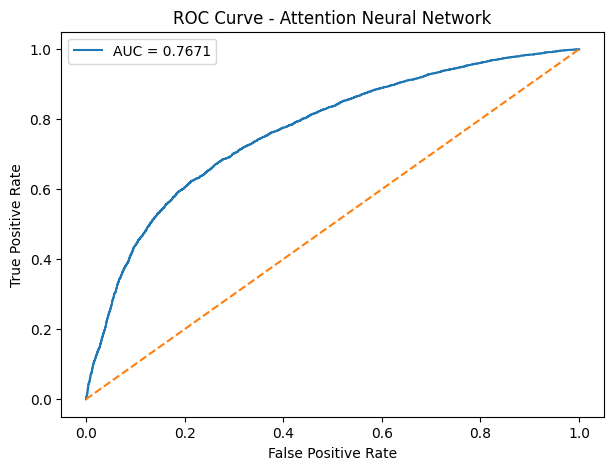

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attention Neural Network")
plt.legend()
plt.show()

In [15]:
overfitting_table = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC", "F1-score"],
    "Train": [
        train_results["Accuracy"],
        train_results["ROC-AUC"],
        train_results["F1-score"]
    ],
    "Validation": [
        val_results["Accuracy"],
        val_results["ROC-AUC"],
        val_results["F1-score"]
    ],
    "Test": [
        test_results["Accuracy"],
        test_results["ROC-AUC"],
        test_results["F1-score"]
    ]
})

overfitting_table["Train-Test Gap"] = overfitting_table["Train"] - overfitting_table["Test"]
overfitting_table

,Metric,Train,Validation,Test,Train-Test Gap
0,Accuracy,0.703209,0.705545,0.703191,0.000018
1,ROC-AUC,0.768966,0.769348,0.767142,0.001824
2,F1-score,0.686652,0.688654,0.685908,0.000745


In [ ]:
class KerasAttentionWrapper(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"

    def __init__(self, keras_model, n_features):
        self.keras_model = keras_model
        self.n_features = n_features
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X_nn = X.reshape(-1, self.n_features, 1)
        prob_1 = self.keras_model.predict(X_nn, verbose=0).ravel()
        prob_0 = 1 - prob_1
        return np.column_stack([prob_0, prob_1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

wrapped_attention_model = KerasAttentionWrapper(attention_model, n_features)


 XAI Technique 1: Permutation Importance

In [22]:
perm_result = permutation_importance(
    wrapped_attention_model,
    X_test_scaled,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring=lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1])
)

perm_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values(by="Importance", ascending=False)

perm_df


,Feature,Importance,Std
3,MAP,0.088268,0.001548
0,AGE,0.039449,0.001981
4,PULSE_PRESSURE,0.036735,0.001113
2,BMI,0.018288,0.001632
5,CHOLESTEROL,0.004267,0.000293
6,GLUCOSE,0.001966,0.000340
8,ALCOHOL,-0.000291,0.000138
9,PHYSICAL_ACTIVITY,-0.000353,0.000179
7,SMOKE,-0.000702,0.000178
1,GENDER,-0.001011,0.000389


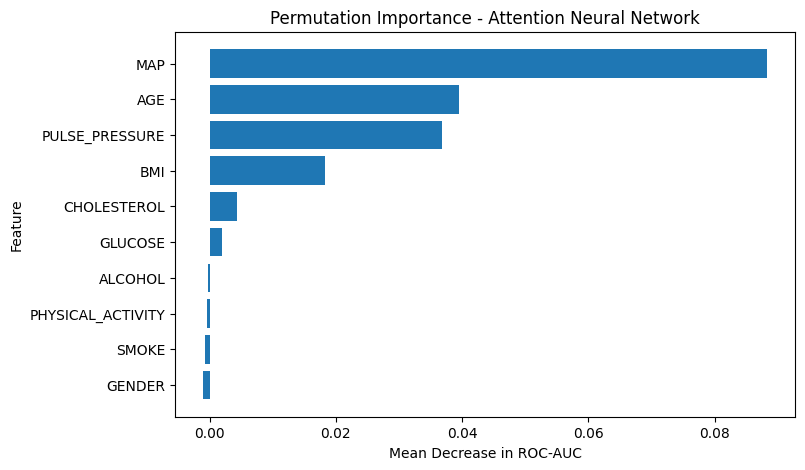

In [23]:
plt.figure(figsize=(8, 5))
plt.barh(perm_df["Feature"], perm_df["Importance"])
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Importance - Attention Neural Network")
plt.gca().invert_yaxis()
plt.show()

XAI Technique 2: SHAP Summary Plot

In [24]:
import shap

100%|██████████| 100/100 [01:05<00:00,  1.54it/s]


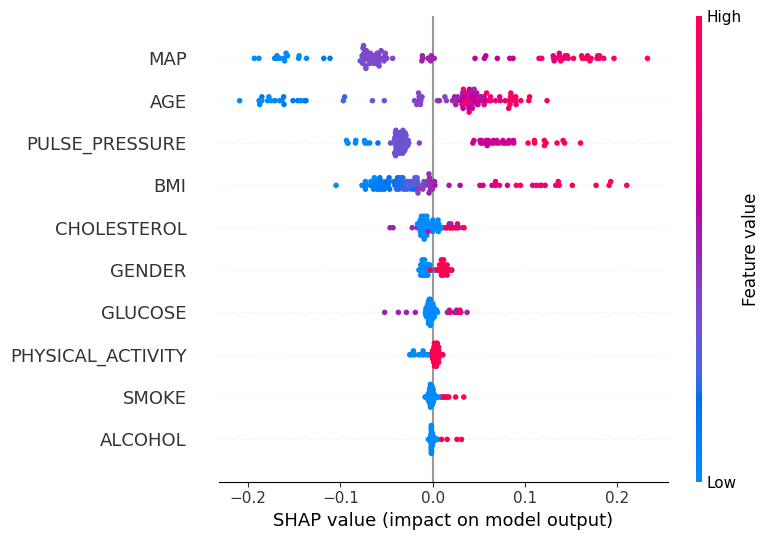

In [25]:
background = shap.sample(pd.DataFrame(X_train_scaled, columns=selected_features), 100, random_state=42)
explain_sample = pd.DataFrame(X_test_scaled, columns=selected_features).sample(100, random_state=42)

shap_explainer = shap.KernelExplainer(
    lambda data: wrapped_attention_model.predict_proba(data)[:, 1],
    background
)

shap_values = shap_explainer.shap_values(explain_sample, nsamples=100)

shap.summary_plot(
    shap_values,
    explain_sample,
    feature_names=selected_features
)

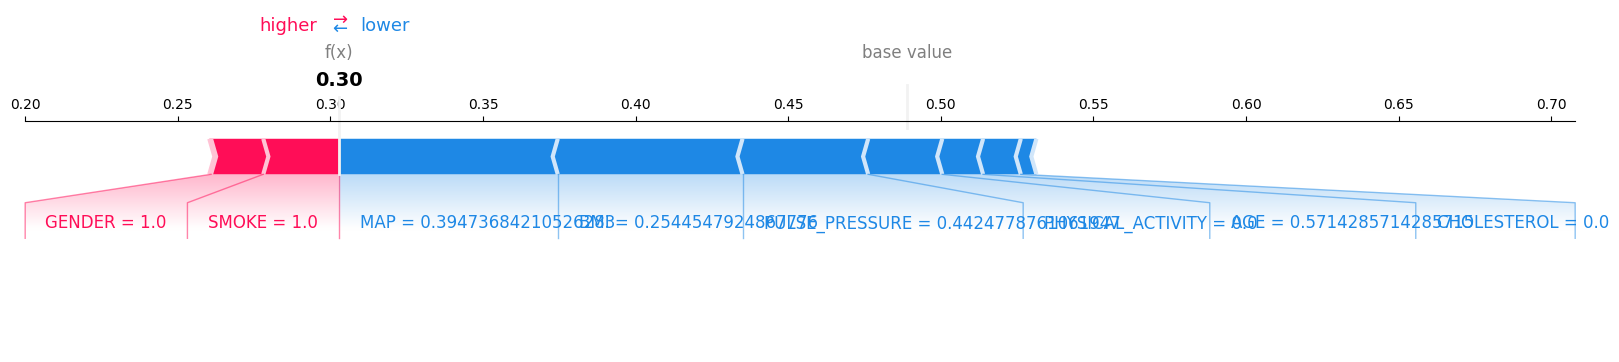

In [26]:
local_index = 0

shap.force_plot(
    shap_explainer.expected_value,
    shap_values[local_index],
    explain_sample.iloc[local_index],
    matplotlib=True
)

XAI Technique 3: LIME Local Explanation

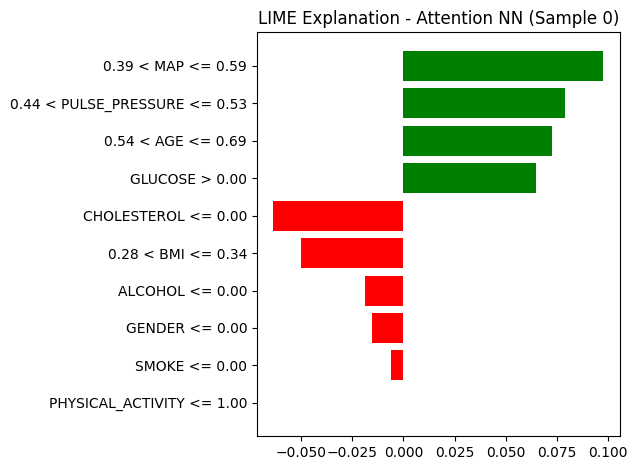

In [28]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=selected_features,
    class_names=["No Cardiovascular Disease", "Cardiovascular Disease"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

sample_index = 0

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[sample_index],
    wrapped_attention_model.predict_proba,
    num_features=len(selected_features)
)

lime_exp.as_pyplot_figure()
plt.title("LIME Explanation - Attention NN (Sample 0)")
plt.tight_layout()
plt.show()


XAI Technique 4: PDP / ICE Plot

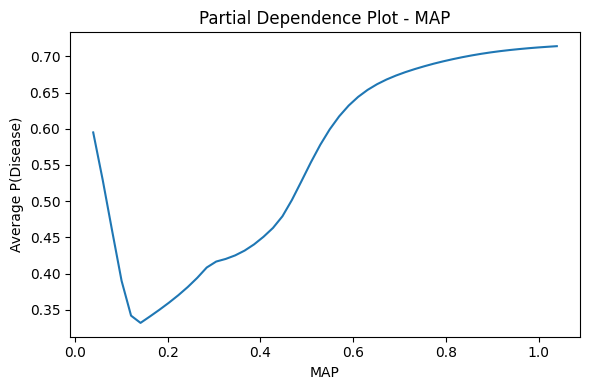

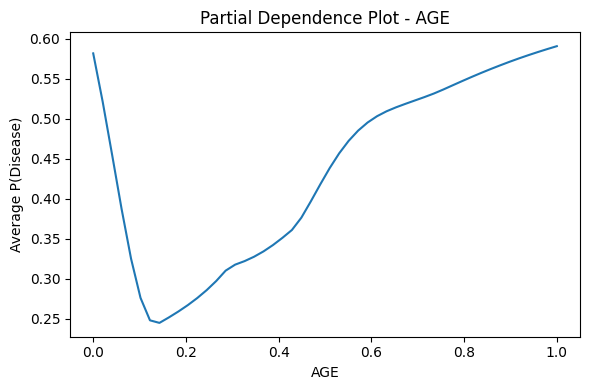

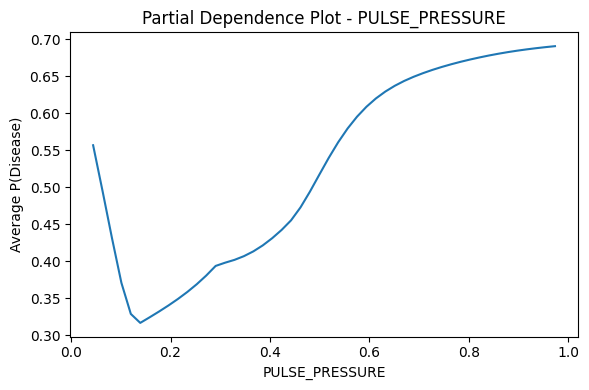

In [30]:
top_features = list(perm_df["Feature"].head(3))
top_feature_indices = [selected_features.index(f) for f in top_features]

X_pdp = X_test_scaled.copy()

for feat_idx, feat_name in zip(top_feature_indices, top_features):
    grid = np.linspace(X_pdp[:, feat_idx].min(), X_pdp[:, feat_idx].max(), 50)
    avg_preds = []
    for val in grid:
        X_temp = X_pdp.copy()
        X_temp[:, feat_idx] = val
        avg_preds.append(wrapped_attention_model.predict_proba(X_temp)[:, 1].mean())

    plt.figure(figsize=(6, 4))
    plt.plot(grid, avg_preds)
    plt.xlabel(feat_name)
    plt.ylabel("Average P(Disease)")
    plt.title(f"Partial Dependence Plot - {feat_name}")
    plt.tight_layout()
    plt.show()


In [ ]:
final_results = pd.DataFrame([
    train_results,
    val_results,
    test_results,
    evaluate_predictions(y_test, test_pred_tuned, test_prob, "Attention NN - Test Tuned Threshold")
])

final_results